In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax.random as jrand

from gvabm.abm_event import sample_event, conditional_sample
from gvabm.abm_ll import city_ll, eval_ds
from gvabm.stat_utils import logrange
from gvabm.city_data import subsampled_city_data, subsample_weights
from gvabm.param_distr import ParamDistr, param_config, CityParams, EventOutcome, GeneralParams, MixedGeneralParams

param_distr = ParamDistr(param_config)

prior = param_distr.get_uniform_prior()
log_prior = param_distr.get_log_uniform_prior()

In [2]:
import os
import numpy as np
import scipy.stats as scs
from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
x0 = np.array([-7.49712599, 38.49844685,  0.70090904, -1.13903331, -4.42167238])
# x0 = np.array(param_distr.sample_range(jrand.PRNGKey(2)))

In [3]:
options = {
    "max_fun_evals": 50 * (D + 2),
    "specify_target_noise": True
    
}
vbmc = VBMC.load(
        "/home/andrew/abm_violence/proc/abm_vbmc_subsampled.pkl",
        new_options=options,
        iteration=None,  # the default: start from the last stored iteration.
        set_random_state=False,  # the default: don't modify the random state
        # (can be set to True for reproducibility).
    )

ModuleNotFoundError: No module named 'param_distr'

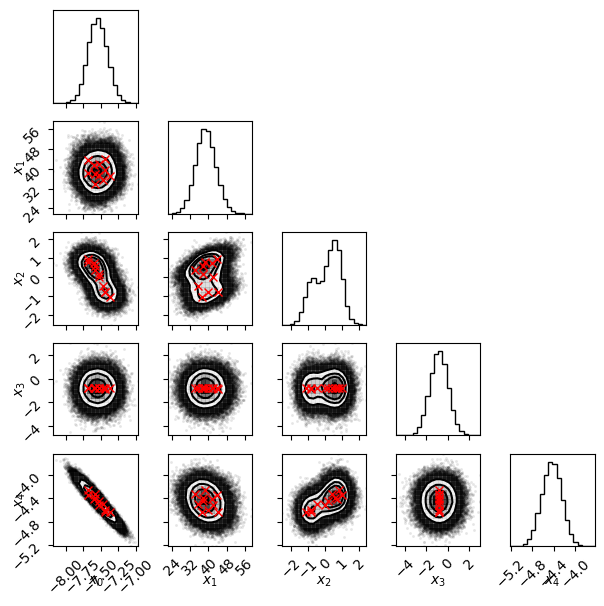

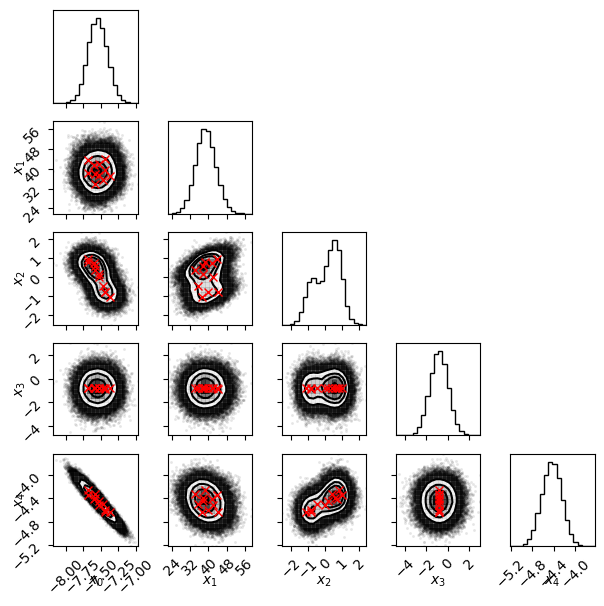

In [15]:
vbmc.vp.plot(plot_vp_centres=True)

In [4]:
print(np.argmax(vbmc.gp.y), vbmc.gp.X[np.argmax(vbmc.gp.y)], vbmc.gp.y[np.argmax(vbmc.gp.y)])
print(np.argmin(vbmc.gp.y), vbmc.gp.X[np.argmin(vbmc.gp.y)], vbmc.gp.y[np.argmin(vbmc.gp.y)])

NameError: name 'vbmc' is not defined

In [6]:
X = vbmc.gp.X
erf = (vbmc.gp.predict(X) - vbmc.gp.y)[0, :]

In [7]:
x_mean = X.mean(axis=0)
print(x_mean)

[ -9.89059996  -2.09684958   2.08711467 -11.21567018 262.67853164]


In [8]:
x_mean = np.array([ 0.04514994,  0,  0.23207941, -0.0,  0.])

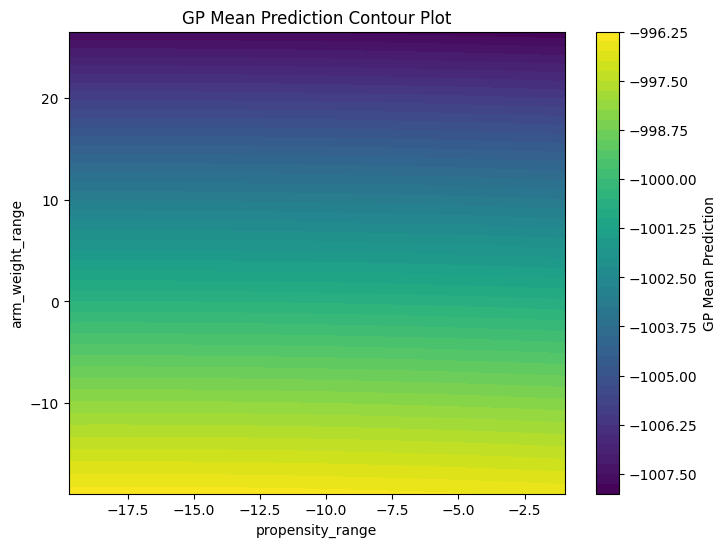

In [9]:
vbmc.gp.predict(x_mean)
i, j = 0, 3  # Example indices for the parameters to plot
x_mesh_i, x_mesh_j = np.meshgrid(
    np.linspace(X[:, i].min(), X[:, i].max(), 100),
    np.linspace(X[:, j].min(), X[:, j].max(), 100),
)
plt.figure(figsize=(8, 6))
x_mean_mat = np.tile(x_mean, (x_mesh_i.size, 1)).reshape(x_mesh_i.shape + (D,))
x_mean_mat[:, :, i] = x_mesh_i
x_mean_mat[:, :, j] = x_mesh_j
mu, s2 = vbmc.gp.predict(x_mean_mat.reshape(-1, D))
mu = mu.reshape(x_mesh_i.shape)
s2 = s2.reshape(x_mesh_i.shape)
plt.contourf(x_mesh_i, x_mesh_j, mu, levels=50, cmap='viridis')
plt.colorbar(label='GP Mean Prediction')
plt.xlabel(param_distr.param_names[i])
plt.ylabel(param_distr.param_names[j])
plt.title('GP Mean Prediction Contour Plot')
plt.show()

In [12]:
vbmc.vp.plot_marginals()

AttributeError: 'VariationalPosterior' object has no attribute 'plot_marginals'

In [7]:
vbmc.plausible_lower_bounds, vbmc.plausible_upper_bounds

(array([[-9. ,  1. , -5. , -1.2, -8. ]], dtype=float32),
 array([[-5. , 95. ,  1. , -0.9, -4. ]], dtype=float32))

In [8]:
samples, ind = vbmc.vp.sample(int(1e6))

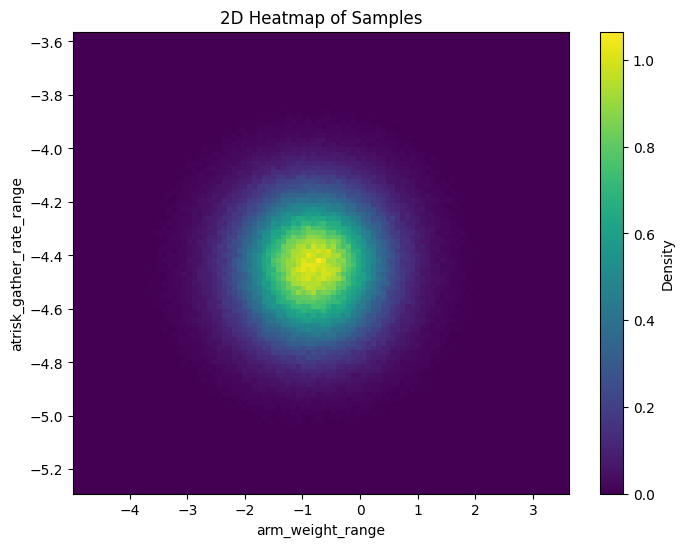

In [11]:
from matplotlib.colors import LogNorm
#Gen 2d heatmap of scatterplot
i, j = 3, 4  # Example indices for the parameters to plot
#hist2d with log scale colormap
plt.figure(figsize=(8, 6))
# plt.hist2d(samples[:, i], samples[:, j], bins=100, density=True, cmap='viridis', norm=LogNorm())
plt.hist2d(samples[:, i], samples[:, j], bins=100, density=True, cmap='viridis') #, norm=LogNorm())
plt.colorbar(label='Density')
plt.xlabel(param_distr.param_names[i])
plt.ylabel(param_distr.param_names[j])
plt.title('2D Heatmap of Samples')
plt.show()

In [39]:
mean_sample = np.mean(samples, axis=0)
print("Param names:", param_distr.param_names)
print(mean_sample)

Param names: ['propensity_range', 'walk_radius_range', 'arm_bias_range', 'arm_weight_range', 'atrisk_gather_rate_range']
[-2.75416106e+00  6.26795527e+03  4.99764670e+00  2.97594420e+00
  2.88996785e+01]


In [ ]:

vbmc = VBMC(P, x0, LB, UB, PLB, PUB, options)
vp, results = vbmc.optimize()
save_file = "proc/abm_vbmc_reweighted.pkl"
vbmc.save(save_file, overwrite=True)

Reshaping x0 to row vector.
Casting plausible lower bounds to floating point.
Casting plausible upper bounds to floating point.
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
     0         10        -735.29       269.33 1842192142.42        2        inf     start warm-up
     1         15        -902.57        53.75       990.49        2        inf     
     2         20        -865.51       108.11      7419.46        2   1.11e+05     
     3         25        -826.17        13.07        62.84        2        961     
     4         30        -827.85         3.07         6.01        2       91.9     
     5         35        -771.95        60.73       230.99        2    3.5e+03     
     6         40        -808.20        26.36        34.07        2        537     
     7         45        -672.72       139.39      1959.01        2   2.93e+04     trim data
     8 

KeyboardInterrupt: 

In [4]:
import os
import numpy as np
import scipy.stats as scs
from pyvbmc import VBMC
D = param_distr.param_count
LB = np.full((1, D), -np.inf); UB = np.full((1, D), np.inf)
PLB = param_distr.range_lower.reshape((1, -1)); PUB = param_distr.range_upper.reshape((1, -1))
x0 = np.array(param_distr.sample_range(jrand.PRNGKey(2)))
save_file = "proc/abm_vbmc.pkl"
new_options = {
    "max_fun_evals": 50 * (D + 2),
    "specify_target_noise": False
}
if os.path.exists(save_file):
    vbmc = VBMC.load(
        save_file,
        new_options=new_options,
        iteration=None,  # the default: start from the last stored iteration.
        set_random_state=False,  # the default: don't modify the random state
        # (can be set to True for reproducibility).
    )

NameError: name 'VBMC' is not defined

In [5]:
print(param_distr.range_lower, param_distr.range_upper, param_distr.param_names)

[-9  1 -3 -1 -8] [-5 95  1  1 -4] ['propensity_range', 'walk_radius_range', 'arm_bias_range', 'arm_weight_range', 'atrisk_gather_rate_range']


In [5]:
# import matplotlib.pyplot as plt
# plt.scatter(samples[:, 0], samples[:, 4], alpha=0.1)

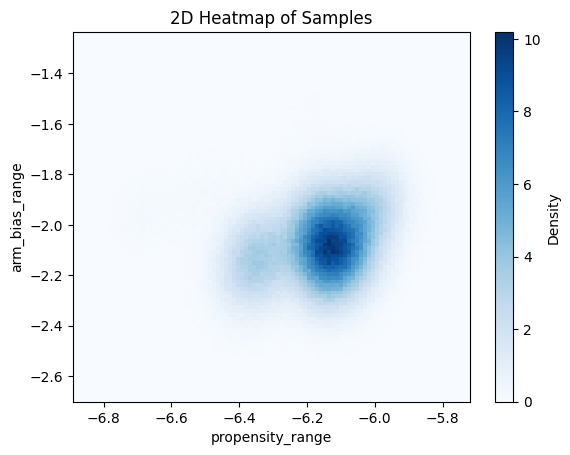

In [ ]:
import os
options = {
    "max_fun_evals": 50 * (D + 2),
    "specify_target_noise": False
    
}
new_options = {
    "max_fun_evals": 50 * (D + 2),
    "specify_target_noise": False
}
save_file = "proc/abm_vbmc.pkl"
if os.path.exists(save_file):
    vbmc = VBMC.load(
        save_file,
        new_options=new_options,
        iteration=None,  # the default: start from the last stored iteration.
        set_random_state=False,  # the default: don't modify the random state
        # (can be set to True for reproducibility).
    )
else:
    vbmc = VBMC(P, x0, LB, UB, PLB, PUB, options)
vp, results = vbmc.optimize()
vbmc.save(save_file, overwrite=True)
with open("models/vbmc_results.pkl", 'wb') as f:
    pickle.dump((vp, results), f)
    

Reshaping x0 to row vector.


Casting plausible lower bounds to floating point.
Casting plausible upper bounds to floating point.
Beginning variational optimization assuming EXACT observations of the log-joint.
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
Evaluating params: [-6.43683577 85.65658569 -2.07986355  0.76322031 -6.3270731 ]
Evaluating params: [-8.28327185 11.33259338 -0.10009764  0.41013472 -4.8254559 ]
Evaluating params: [-8.28698204 20.35852221 -2.24730879 -0.45856137 -7.04452903]


/home/andrew/abm_violence/abm_ll.py:26: RuntimeWarning: divide by zero encountered in log
  eventll += (np.log(event_distr.pdf(fatalities)) - np.log(prob_event))


Evaluating params: [-5.96302226 37.07271395 -1.67558277 -0.26488846 -6.6972189 ]
Evaluating params: [-8.01982945 93.75629225 -1.51939578  0.14085231 -7.34095627]
Evaluating params: [-7.12186013 78.87355388  0.70822528 -0.65122307 -4.90959898]
Evaluating params: [-5.71663422e+00  3.83101274e+01  1.54415522e-02  2.45682162e-01
 -4.06134091e+00]
Evaluating params: [-7.96515529 33.71383134 -0.69459669 -0.92493873 -4.60096624]
Evaluating params: [-7.05674024 76.47181902  0.09142582 -0.24821479 -6.29777822]
Evaluating params: [-8.62520766 90.56424187  0.27169271 -0.23411823 -5.0699053 ]
     0         10    76212109.92 1584138502.44 3132571934.57        2        inf     start warm-up
Evaluating params: [-6.07943987 78.83601165  0.67807177 -0.20430759 -5.05379207]
Evaluating params: [-8.26218688 90.681826    0.1890297   0.40931102 -5.31536184]
Evaluating params: [-8.25310972e+00  7.64727297e+01  4.82476388e-02  4.09051115e-01
 -6.34426752e+00]
Evaluating params: [-5.74410764 90.30437699  0.28

KeyboardInterrupt: 

In [26]:
params = param_distr.sample_range(jrand.PRNGKey(2))
eval = P(params)

In [ ]:

# params = param_distr.sample_range(jrand.PRNGKey(1))
params = GeneralParams(propensity=2e-09, walk_radius=40, arm_bias=0.01, arm_weight=1, atrisk_gathering_rate=1.02e-05)
params = jnp.array([params.propensity, params.walk_radius, params.arm_bias, params.arm_weight, params.atrisk_gathering_rate])
sample_params = param_distr.inverse_transform_sample(params)
# eval_ll = eval_params(jrand.PRNGKey(1), params, param_distr, 10000)

In [ ]:
print(param_config)


{'propensity_range': {'range': (-9, -5), 'logscale': True}, 'walk_radius_range': {'range': (1, 95), 'logscale': False}, 'arm_bias_range': {'range': (-3, 1), 'logscale': True}, 'arm_weight_range': {'range': (-1, 1), 'logscale': True}, 'atrisk_gather_rate_range': {'range': (-8, -4), 'logscale': True}}
